# Experiment zur akutischen Signaltrennung

Ziel dieser Analyse ist der Vergleich von Verfahren zur **Gewinnung von Nutzschall aus einem komplexen akustischen Gesamtsignal**. Der Kontext ist **Predictive Maintenance im Condition Monitoring**, daher erfolgt die Evaluation anhand der Performanz des bereinigten Signals bei einem Isolation Forest Algorithmus zur **Anomalieerkennung**.

In [2]:
# Imports
import soundfile as sf
import matplotlib.pyplot as plt
import numpy as np
from vmdpy import VMD

## 1. Signaleingang

Ein MEMS Mikrofon erfasst Schallwellen als **analoges elektrisches Signal**. Das Signal wird durch einen **Analog-Digital-Wandler (ADC)** in ein **diskretes digitales Signal** umgewandelt und als **.wav** Datei gespeichert. Diese enthält die **Bittiefe** und **Abtastrate** des Signals sowie die **Amplitudenwerte** pro Sample als Nutzdaten.

In [3]:
#Signal laden
signal = "../data/observ_1.wav"

y, sr = sf.read(signal)
print(f"Abtastrate: {sr} Hz (Samples pro Sekunde)")
print(f"Samples insgesamt: {y.shape[0]} ({y.shape[0]/sr:.1f} Sekunden)")

info = sf.info(signal)
print(f"Bittiefe: {info.subtype}")

Abtastrate: 16000 Hz (Samples pro Sekunde)
Samples insgesamt: 80000 (5.0 Sekunden)
Bittiefe: PCM_16


<function matplotlib.pyplot.show(close=None, block=None)>

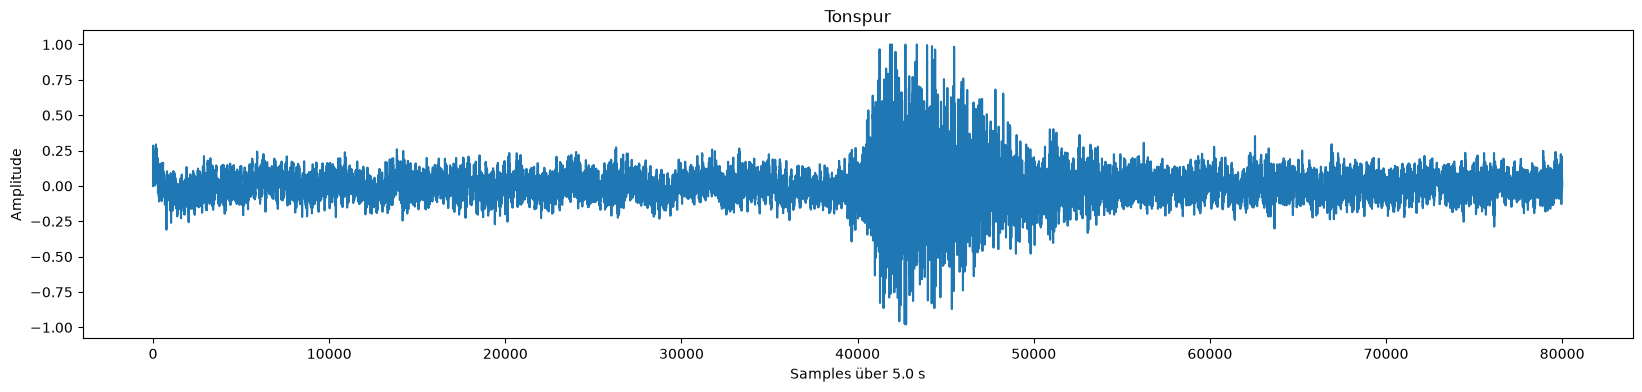

In [4]:
plt.figure(figsize=(20, 4))
plt.title("Tonspur")
plt.plot(y)
plt.xlabel(f"Samples über {len(y)/sr:.1f} s")
plt.ylabel("Amplitude")
plt.show

## 2. Signaltrennung

### 2.1. Zeitbasierte Verfahren

#### 2.1.1. Synchrone Mittelung

McFaden (1986)

**Annahme**: Gesamtsignal y(t) = Maschinensignal + Rauschen | Wobei sich das Maschinensignal einer rotierenden Maschine, periodisch bei jeder Umdrehung wiederholt, das Rauschen hingegen zufällig auftritt.

Die Drehzahl (RPMrpm) muss bekannt sein

In [ ]:
rpm = 1500 
print(f"Die Maschine rotiert mir einer Drehzahl von {rpm} Umdrehungen pro Minute")

Zuerst wird das Signal wird in gleiche Perioden mit der Länge einer Umdrehung geteilt

In [ ]:
periode = int( sr / (rpm/60))
anzahl_perioden = len(y)  // periode

print(f"Eine Umdrehungsperiode enthält {periode} Samples")
print(f"Das Signal enthält {anzahl_perioden} vollständige Umdrehungen")

#Speichern aller Umdrehungsperioden in einer Liste
segmente = []
for i in range(anzahl_perioden):
    segment = y[i * periode :  (i + 1) * periode]
    segmente.append(segment)

In [ ]:
#Alle Umdrehungsperioden geplottet (Output ausklappen)
fig, axes = plt.subplots(anzahl_perioden, 1, figsize=(20, anzahl_perioden * 2))

for i in range(anzahl_perioden):
    segment = y[i * periode : (i + 1) * periode]
    axes[i].plot(segment)
    axes[i].set_title(f"Umdrehungsperiode {i+1} von 125")

plt.tight_layout()
plt.show()

Alle Perioden werden nun übereinandergelegt und deren Durchschnitt berechnet. Dabei verstärkt sich das Maschinensignal - weil es sich wiederholt, addiert es sich konsistent. Das Rauschen hingegen mittelt sich gegen null — weil es zufällig ist, heben sich positive und negative Ausschläge auf.

In [ ]:
segmente_array = np.array(segmente) #Stapelt alle Perioden zu einer Matrix
nutzschall_sm = np.tile(np.mean(segmente_array, axis=0), anzahl_perioden)  #Mittelwert aller Perioden zu einem neuen Signal zusammengefügt
sf.write("../sep/nutzschall_sm.wav", nutzschall_sm, sr)
print(f"nutzschall_fm enthält das durch synchrone Mittelung bereinigte Signal")

In [ ]:
#Mittelwerte anzeigen
print(nutzschall_sm)

In [ ]:
#Vergleich Nutzschall und ursprüngliches Signal

fig, axes = plt.subplots(3,1, figsize=(20, 6))

axes[0].plot(y)
axes[0].set_title("Ursprüngliches Signal")
axes[0].set_xlabel(f"Samples [{len(y)/sr:.1f} s]")
axes[0].set_ylabel("Amplitude")

axes[1].plot(np.mean(segmente_array, axis=0))
axes[1].set_title("Die gemittelte Umdrehungsperiode")
axes[1].set_xlabel(f"1 Periode = {periode} Samples | {rpm} RPM]")
axes[1].set_ylabel("Amplitude")

axes[2].plot(nutzschall_sm)
axes[2].set_title("Nutzschall durch Synchrone Mittelung")
axes[2].set_xlabel(f"Samples")
axes[2].set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

In [ ]:
#Aus Interesse auch der Störschall
stoerschall_sm = y - nutzschall_sm
sf.write("../sep/stoerschall_sm.wav", stoerschall_sm, sr)

#### 2.1.2 Zyklostationäre Analyse

Antoni (2009)

Die zuvor implementierte Synchrone Mittelung wird als Grundlage übernommen - deterministischer Signalanteil

In [ ]:
synchronous_average = np.mean(segmente_array, axis=0) #Spaltenweise Mittelung

Dann wird daraus das Residualsignal berechnet, welches alle zufälligen Anteile enthält

In [ ]:
residual_segmente = segmente_array - synchronous_average  #Ursprungssignal - deterministischen Anteil

In [ ]:
#Aus Interesse Ausgabe als .wav
residual_signal = residual_segmente.flatten()  #1D statt Matrix
sf.write("../sep/stoerschall_za.wav", residual_signal, sr)

Anschließend wird das Residualsignal quadriert und damit in ein Energiesignal umgewandelt

In [ ]:
residual_quadriert = residual_segmente ** 2

und gemittelt

In [ ]:
Px_t = np.mean(residual_quadriert, axis=0)

Plot zum erkennen von zyklostationarität zweiter Ordnung

In [ ]:
t_periode = np.arange(periode) / sr * 1000 #Zeitachse in Milliesekunden

plt.figure()
plt.plot(t_periode, Px_t)
plt.xlabel("Zeit in einer Periode in [ms]")
plt.ylabel("Mittlere Energie")
plt.tight_layout()
plt.show()

FFT - Wechsel in den Frequenzbereich

In [ ]:
fft_Px = np.abs(np.fft.rfft(Px_t))               # Amplitudenspektrum
alpha_achse = np.fft.rfftfreq(periode, d=1/sr)        # Frequenzachse in Hz
plt.figure()
plt.plot(alpha_achse, fft_Px)
plt.xlabel("Zyklische Frequenz α [Hz]")
plt.ylabel("Zyklische Leistung")
plt.title("Zyklische Frequenzen")
plt.tight_layout()
plt.show()

Energiemaske um Nutzschall und Störschall zu trennen

In [ ]:
# Px(t) auf die volle Signallänge überführen → Maske
maske = np.tile(Px_t, anzahl_perioden)  # Form: (anzahl_perioden × periode,)

# Maske normieren auf [0, 1]
maske = maske / np.max(maske)

# Residualsignal als 1D-Array
residual_signal = residual_segmente.flatten()

# Separation
nutzschall_za = residual_signal * maske        # hohe Energie → Maschinenanteil
stoerschall_za = residual_signal * (1 - maske) # niedrige Energie → Störanteil

# Speichern
sf.write("../sep/nutzschall_za.wav", nutzschall_za, sr)
sf.write("../sep/stoerschall_za.wav", stoerschall_za, sr)
print("Separation abgeschlossen")

### 2.2 Frequenzbasierte Verfahren

#### 2.2.4 Bandpass- / Kammfilter

#### 2.2.3. Variational Mode Decomposition

Parameter

In [ ]:
K = 5 #Anzahl gesuchter Moden
alpha = 2000 # Bandbreitenbeschränkung
tau = 0 #Lagrange Schrittweite 
DC = 0 #Keine Gleichanteil-Mode
init = 1       # Mittenfrequenzen gleichmäßig initialisieren
tol = 1e-7     # Konvergenztoleranz – Abbruchkriterium der ADMM-Iteration

Anwendung

In [ ]:
# moden      – Array (K x Samples), eine Zeile pro Mode
# omega      – gelernte Mittenfrequenzen je Mode (normiert auf [0, 0.5])
moden, omega, _ = VMD(y, alpha, tau, K, DC, init, tol)

Umrechnung in Hz

In [ ]:
omega_hz = omega[-1] * sr  # letzte Iteration = konvergierte Werte

print("Gelernte Mittenfrequenzen der Moden:")
for k in range(K):
    print(f"  Mode {k+1}: {omega_hz[k]:.1f} Hz")


Seperation Nutzschall vs. Störschall

In [ ]:

# Drehfrequenz der Maschine in Hz
f_r = rpm / 60.0

# Toleranzband: wie weit darf eine Mittenfrequenz von einer
# Harmonischen entfernt sein, um noch als Nutzschall zu gelten
toleranz_hz = 5.0

# Harmonische der Drehfrequenz die wir erwarten
# n = 1, 2, 3, ... bis zur Nyquist-Frequenz
harmonische = np.arange(1, int((sr / 2) / f_r) + 1) * f_r

nutzschall_vmd = np.zeros(len(y))
stoerschall_vmd = np.zeros(len(y))

for k in range(K):
    # Prüfe ob Mittenfrequenz dieser Mode nahe einer Harmonischen liegt
    abstaende = np.abs(harmonische - omega_hz[k])
    if np.min(abstaende) <= toleranz_hz:
        nutzschall_vmd += moden[k]
        print(f"  Mode {k+1} ({omega_hz[k]:.1f} Hz) → Nutzschall")
    else:
        stoerschall_vmd += moden[k]
        print(f"  Mode {k+1} ({omega_hz[k]:.1f} Hz) → Störschall")

In [ ]:
sf.write("../sep/nutzschall_vmd.wav", nutzschall_vmd, sr)
sf.write("../sep/stoerschall_vmd.wav", stoerschall_vmd, sr)

In [ ]:
fig, axes = plt.subplots(K + 1, 1, figsize=(12, 2 * (K + 1)))

axes[0].plot(y, linewidth=0.5)
axes[0].set_title("Eingangssignal")
axes[0].set_ylabel("Amplitude")

for k in range(K):
    axes[k+1].plot(moden[k], linewidth=0.5)
    axes[k+1].set_title(f"Mode {k+1} – {omega_hz[k]:.1f} Hz")
    axes[k+1].set_ylabel("Amplitude")

axes[-1].set_xlabel("Samples")
plt.tight_layout()
plt.show()

#### 2.2.4 Bandpass- / Kammfilter

Parameter

In [ ]:
delta_f = 5.0  # Bandbreite je Kammzahn in Hz
K_harm = int((sr / 2) // f_r)  # Anzahl nutzbarer Harmonischer

print(f"Bandbreite pro Kammzahn: {delta_f} Hz")
print(f"Anzahl nutzbarer Harmonischer: {K_harm}")

Transformation in Frequenzbereich

In [ ]:
X = np.fft.rfft(y)
freqs = np.fft.rfftfreq(len(y), d=1/sr)

Kammfilter Maske

In [ ]:
maske = np.zeros_like(freqs)
for k in range(1, K_harm + 1):
    f_k = k * f_r
    maske += np.exp(-0.5 * ((freqs - f_k) / delta_f) ** 2)
maske = np.clip(maske, 0, 1)  # Überlappende Gauß-Glocken auf [0, 1] begrenzen

In [ ]:
fig, ax1 = plt.subplots(figsize=(20, 4))
ax1.plot(freqs, np.abs(X), linewidth=0.5, label="Amplitudenspektrum")
ax1.set_xlabel("Frequenz [Hz]")
ax1.set_ylabel("Amplitude")

ax2 = ax1.twinx()
ax2.plot(freqs, maske, color="red", linewidth=1.0, label="Kammfilter-Maske")
ax2.set_ylabel("Maskenwert [0, 1]")

fig.suptitle("Spektrum mit Kammfilter-Maske an den Harmonischen von f_r")
fig.tight_layout()
plt.show()

Maske anwenden und Rücktransformation

In [ ]:
X_nutz = X * maske
X_stoer = X * (1 - maske)

nutzschall_kf = np.fft.irfft(X_nutz, n=len(y))
stoerschall_kf = np.fft.irfft(X_stoer, n=len(y))

sf.write("../sep/nutzschall_kf.wav", nutzschall_kf, sr)
sf.write("../sep/stoerschall_kf.wav", stoerschall_kf, sr)

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(20, 6))

axes[0].plot(y)
axes[0].set_title("Ursprüngliches Signal")
axes[0].set_xlabel(f"Samples [{len(y)/sr:.1f} s]")
axes[0].set_ylabel("Amplitude")

axes[1].plot(nutzschall_kf)
axes[1].set_title("Nutzschall (Kammfilterung)")
axes[1].set_ylabel("Amplitude")

axes[2].plot(stoerschall_kf)
axes[2].set_title("Störschall (Kammfilterung)")
axes[2].set_ylabel("Amplitude")

fig.tight_layout()
plt.show()

#### 2.2.5 Spektralsubtraktion

In [ ]:
from scipy.signal import stft, istft

In [ ]:
# STFT-Parameter
fenster_laenge = periode  # Analysefenster an Rotationsperiode gekoppelt
overlap = fenster_laenge // 2  # 50% Überlappung, Hanning-Fenster

freqs_stft, zeit_stft, Y_stft = stft(y, fs=sr, window='hann',
                                      nperseg=fenster_laenge, noverlap=overlap)

In [ ]:
# Rauschschätzung aus einem Referenzabschnitt ohne Nutzschall
rauschreferenz_ende_s = 1.0  # TODO: an SIPREMA-Messung anpassen
rauschreferenz_ende_idx = np.searchsorted(zeit_stft, rauschreferenz_ende_s)

rauschspektrum = np.mean(np.abs(Y_stft[:, :rauschreferenz_ende_idx]), axis=1)  # μ(f)

In [ ]:
betrag_y = np.abs(Y_stft)
phase_y = np.angle(Y_stft)

betrag_nutz = betrag_y - rauschspektrum[:, np.newaxis]
betrag_nutz = np.maximum(betrag_nutz, 0)  # Halbwellen-Gleichrichtung

Y_nutz = betrag_nutz * np.exp(1j * phase_y)
Y_stoer = Y_stft - Y_nutz

In [ ]:
_, nutzschall_ss = istft(Y_nutz, fs=sr, window='hann',
                          nperseg=fenster_laenge, noverlap=overlap)
_, stoerschall_ss = istft(Y_stoer, fs=sr, window='hann',
                           nperseg=fenster_laenge, noverlap=overlap)

sf.write("../sep/nutzschall_ss.wav", nutzschall_ss, sr)
sf.write("../sep/stoerschall_ss.wav", stoerschall_ss, sr)

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(20, 6))

axes[0].plot(y)
axes[0].set_title("Ursprüngliches Signal")
axes[0].set_ylabel("Amplitude")

axes[1].plot(nutzschall_ss)
axes[1].set_title("Nutzschall (Spektralsubtraktion)")
axes[1].set_ylabel("Amplitude")

axes[2].plot(stoerschall_ss)
axes[2].set_title("Störschall (Spektralsubtraktion)")
axes[2].set_ylabel("Amplitude")

fig.tight_layout()
plt.show()

#### 2.2.6 HPSS

In [ ]:
from scipy.ndimage import median_filter

In [ ]:
# --- STFT des Eingangssignals ---
n_fft = 2048
hop = n_fft // 4

f, t, X = stft(y, fs=sr, nperseg=n_fft, noverlap=n_fft - hop)
X_betrag = np.abs(X)

In [ ]:
# --- Medianfilterung entlang Zeit- bzw. Frequenzachse ---
L_h = 17  # Filterlänge in Frames (Zeitachse) -> verstärkt harmonische Grate
L_p = 17  # Filterlänge in Bins (Frequenzachse) -> verstärkt perkussive Grate

Y_h = median_filter(X_betrag, size=(1, L_h))
Y_p = median_filter(X_betrag, size=(L_p, 1))

In [ ]:
# --- Weiche Maskenbildung (Driedger2014) ---
p_maske = 2.0
eps = 1e-10
M_h = Y_h**p_maske / (Y_h**p_maske + Y_p**p_maske + eps)
M_p = 1.0 - M_h

In [ ]:
# --- Anwendung der Masken auf das komplexe Spektrogramm --- Plot fehlt noch
X_h = M_h * X
X_p = M_p * X

In [ ]:
# --- Rücktransformation in den Zeitbereich ---
import os

_, nutzschall_hpss = istft(X_h, fs=sr, nperseg=n_fft, noverlap=n_fft - hop)
_, stoerschall_hpss = istft(X_p, fs=sr, nperseg=n_fft, noverlap=n_fft - hop)

os.makedirs('../sep', exist_ok=True)

sf.write('../sep/nutzschall_hpss.wav', nutzschall_hpss.astype(np.float32), sr)
sf.write('../sep/stoerschall_hpss.wav', stoerschall_hpss.astype(np.float32), sr)

In [ ]:
#Diese Farbgebung global übernehmen. Gesamtsignal = Blau, Nutzschall = grün, Störschall = rot
zeit = np.arange(len(nutzschall_hpss)) / sr

fig, achsen = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

achsen[0].plot(zeit, nutzschall_hpss, color='tab:blue', linewidth=0.7)
achsen[0].set_title('Nutzschall (harmonischer Anteil, HPSS)')
achsen[0].set_ylabel('Amplitude')

achsen[1].plot(zeit, stoerschall_hpss, color='tab:red', linewidth=0.7)
achsen[1].set_title('Störschall (perkussiver Anteil, HPSS)')
achsen[1].set_xlabel('Zeit [s]')
achsen[1].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

#### 2.2.7 MMSE-STSA

In [ ]:
from scipy.special import ive  # exponentiell skalierte Bessel-Funktionen (numerisch stabil)

In [ ]:
# --- STFT des Eingangssignals ---
n_fft = 2048
hop = n_fft // 4

f, t, Y = stft(y, fs=sr, nperseg=n_fft, noverlap=n_fft - hop)
Y_betrag = np.abs(Y)
Y_phase = np.angle(Y)

In [ ]:
# --- Störschallvarianz aus den ersten Rahmen schätzen ---
# Annahme: die ersten n_rauschframes Frames sind störschalldominiert
n_rauschframes = 10
lambda_d = np.mean(Y_betrag[:, :n_rauschframes] ** 2, axis=1, keepdims=True)

In [ ]:

# --- Iterative decision-directed Schätzung ---
alpha = 0.98
eps = 1e-10

n_bins, n_frames = Y_betrag.shape
A_geschaetzt = np.zeros((n_bins, n_frames))
xi = np.zeros((n_bins, n_frames))

for n in range(n_frames):
    gamma_n = Y_betrag[:, n] ** 2 / (lambda_d[:, 0] + eps)

    if n == 0:
        xi_n = np.maximum(gamma_n - 1, 0)
    else:
        xi_n = alpha * (A_geschaetzt[:, n - 1] ** 2 / (lambda_d[:, 0] + eps)) \
               + (1 - alpha) * np.maximum(gamma_n - 1, 0)
    xi[:, n] = xi_n

    nu_n = np.maximum(xi_n / (1 + xi_n) * gamma_n, eps)

    # G_k(n) mit exponentiell skalierten Bessel-Funktionen (vermeidet Overflow)
    G_n = (np.sqrt(np.pi) / 2) * (np.sqrt(nu_n) / (gamma_n + eps)) * \
          ((1 + nu_n) * ive(0, nu_n / 2) + nu_n * ive(1, nu_n / 2))
    G_n = np.clip(np.nan_to_num(G_n, nan=1.0), 0.0, 1.0)

    A_geschaetzt[:, n] = G_n * Y_betrag[:, n]

In [ ]:
# --- Rekonstruktion mit ursprünglicher Phase ---
X_h = A_geschaetzt * np.exp(1j * Y_phase)
D_h = Y - X_h  # Störschallschätzung als Residuum

_, nutzschall_mmse = istft(X_h, fs=sr, nperseg=n_fft, noverlap=n_fft - hop)
_, stoerschall_mmse = istft(D_h, fs=sr, nperseg=n_fft, noverlap=n_fft - hop)

os.makedirs('../sep', exist_ok=True)
sf.write('../sep/nutzschall_mmse.wav', nutzschall_mmse.astype(np.float32), sr)
sf.write('../sep/stoerschall_mmse.wav', stoerschall_mmse.astype(np.float32), sr)

#### 2.2.8 NMF

In [ ]:
# --- STFT ---
n_fft = 2048
hop = n_fft // 4

f, t, Y = stft(y, fs=sr, nperseg=n_fft, noverlap=n_fft - hop)
V = np.abs(Y)

eps = 1e-10
n_bins, n_frames = V.shape

In [ ]:
# --- NMF-Initialisierung ---
K = 8  # Anzahl Basisvektoren (Hyperparameter)
rng = np.random.default_rng(42)
W = rng.uniform(0.5, 1.0, size=(n_bins, K))
H = rng.uniform(0.5, 1.0, size=(K, n_frames))

In [ ]:
# --- Multiplikative Update-Regeln (KL-Divergenz, Lee & Seung 2001) ---
n_iter = 200
einsen = np.ones_like(V)

for i in range(n_iter):
    V_approx = W @ H + eps
    H *= (W.T @ (V / V_approx)) / (W.T @ einsen + eps)

    V_approx = W @ H + eps
    W *= ((V / V_approx) @ H.T) / (einsen @ H.T + eps)

In [ ]:
# --- Zuordnung der Basisvektoren über Periodizität der Aktivierung ---
# periode: Rotationsperiode in Frames, aus der McFadden-Implementierung übernommen
n_lags = int(periode)
periodizitaet = np.zeros(K)

for k in range(K):
    aktivierung = H[k, :]
    if n_lags < len(aktivierung):
        periodizitaet[k] = np.corrcoef(aktivierung[:-n_lags], aktivierung[n_lags:])[0, 1]

schwelle = 0.3
nutzschall_komponenten = np.where(periodizitaet >= schwelle)[0]
stoerschall_komponenten = np.where(periodizitaet < schwelle)[0]

In [ ]:
# --- Rekonstruktion der Teilspektrogramme ---
V_nutzschall = W[:, nutzschall_komponenten] @ H[nutzschall_komponenten, :]
V_stoerschall = W[:, stoerschall_komponenten] @ H[stoerschall_komponenten, :]

# --- Weiche Maskierung und Rücktransformation ---
M_nutzschall = V_nutzschall / (V_nutzschall + V_stoerschall + eps)
M_stoerschall = 1 - M_nutzschall

X_nutzschall = M_nutzschall * Y
X_stoerschall = M_stoerschall * Y

_, nutzschall_nmf = istft(X_nutzschall, fs=sr, nperseg=n_fft, noverlap=n_fft - hop)
_, stoerschall_nmf = istft(X_stoerschall, fs=sr, nperseg=n_fft, noverlap=n_fft - hop)

In [ ]:
os.makedirs('../sep', exist_ok=True)
sf.write('../sep/nutzschall_nmf.wav', nutzschall_nmf.astype(np.float32), sr)
sf.write('../sep/stoerschall_nmf.wav', stoerschall_nmf.astype(np.float32), sr)

#### 2.2.9 RPCA

In [ ]:
# --- STFT ---
n_fft = 2048
hop = n_fft // 4
f, t, Y_stft = stft(y, fs=sr, nperseg=n_fft, noverlap=n_fft - hop)
M = np.abs(Y_stft)

In [ ]:
# --- Hilfsfunktionen ---
def schwellenwert_weich(X, tau):
    return np.sign(X) * np.maximum(np.abs(X) - tau, 0)

def schwellenwert_singulaerwerte(X, tau):
    U, Sigma, Vt = np.linalg.svd(X, full_matrices=False)
    Sigma_geschwellt = np.maximum(Sigma - tau, 0)
    return U @ np.diag(Sigma_geschwellt) @ Vt

In [ ]:
# --- Principal Component Pursuit (Candès et al. 2011), gelöst via ALM (Lin et al. 2010) ---
n_zeilen, n_spalten = M.shape
lam = 1.0 / np.sqrt(max(n_zeilen, n_spalten))
mu = 1.25 / np.linalg.norm(M, 2)
rho = 1.5

L = np.zeros_like(M)
S = np.zeros_like(M)
Y_lagrange = np.zeros_like(M)

n_iter = 100
toleranz = 1e-7
norm_M = np.linalg.norm(M, 'fro')

for i in range(n_iter):
    L = schwellenwert_singulaerwerte(M - S + Y_lagrange / mu, 1.0 / mu)
    S = schwellenwert_weich(M - L + Y_lagrange / mu, lam / mu)

    residuum = M - L - S
    Y_lagrange += mu * residuum
    mu *= rho

    fehler = np.linalg.norm(residuum, 'fro') / norm_M
    if fehler < toleranz:
        break

In [ ]:
# --- Zuordnung: L (niedrigrangig, repetitiv) -> Nutzschall, S (spärlich, transient) -> Störschall ---
M_nutzschall = np.clip(L, 0, None)
M_stoerschall = np.clip(S, 0, None)
M_summe = M_nutzschall + M_stoerschall + 1e-10

maske_nutzschall = M_nutzschall / M_summe
maske_stoerschall = M_stoerschall / M_summe

X_nutzschall = maske_nutzschall * Y_stft
X_stoerschall = maske_stoerschall * Y_stft

_, nutzschall_rpca = istft(X_nutzschall, fs=sr, nperseg=n_fft, noverlap=n_fft - hop)
_, stoerschall_rpca = istft(X_stoerschall, fs=sr, nperseg=n_fft, noverlap=n_fft - hop)

In [ ]:
os.makedirs('../sep', exist_ok=True)
sf.write('../sep/nutzschall_rpca.wav', nutzschall_rpca.astype(np.float32), sr)
sf.write('../sep/stoerschall_rpca.wav', stoerschall_rpca.astype(np.float32), sr)

#### 2.2.10 Wahrnehmungsbasiert

In [ ]:
from scipy.ndimage import maximum_filter

In [ ]:
# --- STFT ---
n_fft = 2048
hop = n_fft // 4
f_hz, t_frames, Y_stft = stft(y, fs=sr, nperseg=n_fft, noverlap=n_fft - hop)
n_bins, n_frames = Y_stft.shape

In [ ]:
# --- Frequenz-Tonheits-Transformation (Bark-Skala, Zwicker-Näherung) ---
def frequenz_zu_bark(f):
    return 13 * np.arctan(0.00076 * f) + 3.5 * np.arctan((f / 7500) ** 2)

bark_pro_bin = frequenz_zu_bark(f_hz)

In [ ]:
# --- Ruhehörschwelle nach Terhardt (mit sinnvollem Frequenz-Floor) ---
def ruhehoerschwelle(f_hz):
    f_khz = np.maximum(f_hz, 20) / 1000  # Floor bei 20 Hz statt 1 Hz, vermeidet Explosion bei DC
    return (3.64 * f_khz ** -0.8 + 1e-3 * f_khz ** 4) - 6.5 * np.exp(-0.6 * (f_khz - 3.3) ** 2)

L_TH = ruhehoerschwelle(f_hz)
print("Bereich L_TH nach Fix:", L_TH.min(), "bis", L_TH.max())  # sollte jetzt ~ -5 bis ~25 liegen

In [ ]:
# --- Kalibrierung: rohe dB-Skala auf plausible SPL-Größenordnung heben ---
ziel_pegel_db = 90  # angenommener Pegel für die lautesten Signalanteile
kalibrierungsoffset = ziel_pegel_db - Y_db.max()
print("Kalibrierungsoffset:", kalibrierungsoffset, "dB")

Y_db = Y_db + kalibrierungsoffset  # überschreibt Y_db direkt, damit der Rest der Pipeline unverändert bleibt

In [ ]:
# --- Teilton-Extraktion (lokale Maxima pro Frame) ---
def teiltoene_extrahieren(spektrum_db, bark_pro_bin, min_pegel=0, min_abstand_bark=0.5):
    # 1. Grobe Kandidaten: lokale Maxima über der Schwelle
    kandidaten = []
    for k in range(1, len(spektrum_db) - 1):
        if spektrum_db[k] > spektrum_db[k - 1] and spektrum_db[k] > spektrum_db[k + 1] \
           and spektrum_db[k] > min_pegel:
            kandidaten.append(k)

    if not kandidaten:
        return np.array([], dtype=int)

    # 2. Nach Pegel absteigend sortieren, dann gierig auswählen
    #    mit Mindestabstand in Bark, um Leckeffekt-Rippel auszuschließen
    kandidaten_sortiert = sorted(kandidaten, key=lambda k: -spektrum_db[k])
    akzeptiert = []
    for k in kandidaten_sortiert:
        if all(abs(bark_pro_bin[k] - bark_pro_bin[a]) >= min_abstand_bark for a in akzeptiert):
            akzeptiert.append(k)

    return np.array(sorted(akzeptiert))

In [ ]:
# --- Mithörschwellenbeitrag (vereinfachtes Terhardt-Modell) ---
def mithoerschwellenbeitrag(bark_maskierer, pegel_maskierer, bark_ziel):
    dz = bark_ziel - bark_maskierer
    if dz <= 0:
        steigung = 27.0  # s1
    elif abs(dz) <= 1:
        steigung = -24 - 0.23 + 0.2 * pegel_maskierer  # s2 (f_mu-Term vereinfacht)
    else:
        steigung = -12 + 0.13 * pegel_maskierer  # s3
    return pegel_maskierer + steigung * dz


In [ ]:
# --- Pegelüberschuss und Spektraltonhöhengewicht pro Frame ---
f_m = 700.0  # Dominanzfrequenz in Hz
eps = 1e-10

alle_teiltoene = []  # Liste von (frame, bin, freq, pegel, LX, WS)
# Y_db NICHT neu berechnen -- wird bereits kalibriert aus Zelle 102 übernommen

for n in range(n_frames):
    spektrum_db = Y_db[:, n]
    peak_bins = teiltoene_extrahieren(
        spektrum_db, bark_pro_bin,
        min_pegel=np.max(spektrum_db) - 25,
        min_abstand_bark=0.5
    )

    for mu in peak_bins:
        L_mu = spektrum_db[mu]
        maskierungssumme = 0.0
        for nu in peak_bins:
            if nu == mu:
                continue
            LE = mithoerschwellenbeitrag(bark_pro_bin[nu], spektrum_db[nu], bark_pro_bin[mu])
            maskierungssumme += 10 ** (LE / 20)

        LX_mu = L_mu - 10 * np.log10(maskierungssumme ** 2 + 10 ** (L_TH[mu] / 10) + eps)

        if LX_mu >= 0:
            WS_mu = (1 - np.exp(-LX_mu / 15)) * \
                    (1 + 0.007 * (f_hz[mu] / f_m - f_m / f_hz[mu]) ** 2) ** -0.5
        else:
            WS_mu = 0.0

        alle_teiltoene.append((n, mu, f_hz[mu], L_mu, LX_mu, WS_mu))

In [ ]:
# --- Teiltonlinien: Kontinuitätsverkettung ---
max_freq_abstand_bark = 0.2
max_unterbrechung_frames = int(0.5 * sr / hop)  # Überschussschwelle ~500ms

teiltonlinien = []
aktive_linien = []  # (letzter_frame, letzter_bin, linie)

for eintrag in sorted(alle_teiltoene, key=lambda e: e[0]):
    n, k, freq, pegel, lx, ws = eintrag
    passende_linie = None
    for linie_info in aktive_linien:
        letzter_frame, letzter_bin, linie = linie_info
        if (n - letzter_frame) <= max_unterbrechung_frames and \
           abs(bark_pro_bin[k] - bark_pro_bin[letzter_bin]) <= max_freq_abstand_bark:
            passende_linie = linie_info
            break
    if passende_linie:
        passende_linie[2].append((n, k, freq, pegel, ws))
        aktive_linien[aktive_linien.index(passende_linie)] = (n, k, passende_linie[2])
    else:
        neue_linie = [(n, k, freq, pegel, ws)]
        aktive_linien.append((n, k, neue_linie))
        teiltonlinien.append(neue_linie)

In [ ]:
# --- Einsatz-Integration: Clusterbildung (H_CLR) nach Einsatzzeit ---
einsatz_toleranz_frames = int(0.04 * sr / hop)  # ~40ms

linien_mit_einsatz = sorted([(linie[0][0], linie) for linie in teiltonlinien], key=lambda x: x[0])

cluster = []
for einsatz, linie in linien_mit_einsatz:
    passendes_cluster = None
    for c in cluster:
        if abs(c['einsatz'] - einsatz) <= einsatz_toleranz_frames:
            passendes_cluster = c
            break
    if passendes_cluster:
        passendes_cluster['linien'].append(linie)
    else:
        cluster.append({'einsatz': einsatz, 'linien': [linie]})

In [ ]:
# --- Sequentielle Integration: H_CLR-Cluster über Zeit zu Strömen verketten ---
# (Baumann 1995, Abschnitt 3.9 -- Kohärenz- und Gewichtsregel, nach van Noorden 1975)

def mittlere_tonhoehe(cluster, bark_pro_bin):
    bins = [linie[0][1] for linie in cluster['linien']]
    return np.mean(bark_pro_bin[bins])

def cluster_gewicht(cluster):
    gewichte = [linie[0][4] for linie in cluster['linien']]
    return np.mean(gewichte) if gewichte else 0.0

T_A_suchintervall_frames = int(0.15 * sr / hop)

for c in cluster:
    c['tonhoehe'] = mittlere_tonhoehe(c, bark_pro_bin)
    c['gewicht'] = cluster_gewicht(c)

cluster_sortiert = sorted(cluster, key=lambda c: c['einsatz'])
zugeordnet = [False] * len(cluster_sortiert)
stroeme = []

for i, c in enumerate(cluster_sortiert):
    if zugeordnet[i]:
        continue
    strom = [c]
    zugeordnet[i] = True
    aktueller = c

    while True:
        kandidaten = [
            (j, k) for j, k in enumerate(cluster_sortiert)
            if not zugeordnet[j]
            and 0 < (k['einsatz'] - aktueller['einsatz']) <= T_A_suchintervall_frames
        ]
        if not kandidaten:
            break

        # Sequentielle Gruppierungsbedingung 1 (Kohärenz): nächste Tonhöhe
        diffs = [abs(k['tonhoehe'] - aktueller['tonhoehe']) for _, k in kandidaten]
        min_diff = min(diffs)
        naechste = [(j, k) for (j, k), d in zip(kandidaten, diffs) if d == min_diff]

        # Sequentielle Gruppierungsbedingung 2 (Gewicht): Tiebreak
        if len(naechste) > 1:
            j, gewaehlter = max(naechste, key=lambda jk: jk[1]['gewicht'])
        else:
            j, gewaehlter = naechste[0]

        strom.append(gewaehlter)
        zugeordnet[j] = True
        aktueller = gewaehlter

    stroeme.append(strom)


In [ ]:
# --- Klassifikation: periodische Ströme -> Nutzschall, übrige -> Störschall ---
# periode: Rotationsperiode in Frames, aus der McFadden-Implementierung übernommen
nutzschall_stroeme = []
stoerschall_stroeme = []

for strom in stroeme:
    einsatzzeiten = sorted(c['einsatz'] for c in strom)
    periodisch = False
    if len(einsatzzeiten) >= 2:
        abstaende = np.diff(einsatzzeiten)
        if np.any(np.abs(abstaende - periode) < periode * 0.15):
            periodisch = True
    if periodisch:
        nutzschall_stroeme.append(strom)
    else:
        stoerschall_stroeme.append(strom)

In [ ]:
# --- Rekonstruktion: Maskierung basierend auf zugeordneten Strömen ---
maske_nutzschall = np.zeros((n_bins, n_frames))
maske_stoerschall = np.zeros((n_bins, n_frames))

for strom in nutzschall_stroeme:
    for c in strom:
        for linie in c['linien']:
            for (n, k, freq, pegel, ws) in linie:
                maske_nutzschall[k, n] = max(maske_nutzschall[k, n], ws)

for strom in stoerschall_stroeme:
    for c in strom:
        for linie in c['linien']:
            for (n, k, freq, pegel, ws) in linie:
                maske_stoerschall[k, n] = max(maske_stoerschall[k, n], ws)

In [ ]:
# Weichzeichnung der Punktmasken zu flächigen Masken
maske_nutzschall = maximum_filter(maske_nutzschall, size=(3, 3))
maske_stoerschall = maximum_filter(maske_stoerschall, size=(3, 3))

summe = maske_nutzschall + maske_stoerschall + eps
maske_nutzschall_final = maske_nutzschall / summe
maske_stoerschall_final = maske_stoerschall / summe

X_nutzschall = maske_nutzschall_final * Y_stft
X_stoerschall = maske_stoerschall_final * Y_stft

_, nutzschall_baumann = istft(X_nutzschall, fs=sr, nperseg=n_fft, noverlap=n_fft - hop)
_, stoerschall_baumann = istft(X_stoerschall, fs=sr, nperseg=n_fft, noverlap=n_fft - hop)

In [ ]:
os.makedirs('../sep', exist_ok=True)
sf.write('../sep/nutzschall_baumann.wav', nutzschall_baumann.astype(np.float32), sr)
sf.write('../sep/stoerschall_baumann.wav', stoerschall_baumann.astype(np.float32), sr)

In [ ]:
print("Anzahl extrahierter Teiltöne:", len(alle_teiltoene))
print("Anzahl Teiltonlinien:", len(teiltonlinien))
print("Anzahl Cluster (H_CLR):", len(cluster))
print("Anzahl Ströme:", len(stroeme))
print("Anzahl Nutzschall-Ströme:", len(nutzschall_stroeme))
print("Anzahl Störschall-Ströme:", len(stoerschall_stroeme))
print("Max Wert Maske Nutzschall:", maske_nutzschall.max())
print("Max Wert Maske Störschall:", maske_stoerschall.max())
print("Max |nutzschall_baumann|:", np.max(np.abs(nutzschall_baumann)))
print("Max |stoerschall_baumann|:", np.max(np.abs(stoerschall_baumann)))

In [ ]:
print("Bereich Y_db (roh):", Y_db.min(), "bis", Y_db.max())
print("Bereich L_TH (Ruhehörschwelle):", L_TH.min(), "bis", L_TH.max())

# ein paar Beispiel-LX-Werte direkt inspizieren
beispiel_werte = [e[4] for e in alle_teiltoene[:20]]
print("Beispiel LX-Werte:", beispiel_werte)

## 3. Vorverarbeitung

## 4. Anomalieerkennung

In [ ]:
#. Berechnung von zeit- und frequenzbasierten Merkmalen wie bei SIPREMA üblich für jedes Snippet

In [ ]:
# Isolation Forest für jedes Snippet sowie dem ungetrennten Baseline Signal

## 5. Evaluation

In [ ]:
#. Evaluation der Performanz der Anomalieerkennung mit Confusion Matrix und den üblichen Metriken. 

In [ ]:
#. Darstellung der Performanz der Methoden im Vergleich zur Baseline in der Anomalieerkennung (Underfitting? Overfitting?)